# ReGRID model analysis

### Energy system configurations

Last update: 30 January, 2026

Dependency: model.py

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os

In [28]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'high' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [29]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_high_moderate_ccs-biomass


In [30]:
########### Input data ##########

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str, 'pref_code':str})
REGION = region_list.index.to_list() # All nodes
SUBSTATION = pd.read_csv('input/region_substation.csv', index_col=0, dtype={'region':str})['region'].to_list() # Substation nodes
NODE = [r for r in REGION if r not in SUBSTATION] # Terminal nodes
AREA = region_list['DSN'].copy() # Distribution area
REGION06 = pd.Series(data=[f"{r:>6}".replace(' ','_') for r in REGION], index=REGION) # Region list (6 digit code)
SPREGION = {}

if BOUNDARY != 'japan':
    REGION = region_list[region_list['TSO'] == BOUNDARY].index.to_list() # All nodes
    SUBSTATION = [r for r in REGION if r in SUBSTATION] # Substation nodes
    NODE = [r for r in REGION if r not in SUBSTATION] # Terminal nodes
    AREA = region_list[region_list['TSO'] == BOUNDARY]['DSN'].copy() # Distribution area

# Time series list
TIME = pd.read_csv('input/%sh/time_%s.csv' % (STEP,TERM))['time'].to_list()
TIME04 = pd.Series(data=[f"{r:>4}".replace(' ','_') for r in TIME], index=TIME) # Time series (4 digit)
T_LEN = len(TIME)

# Time series scaling
if T_LEN * STEP == 8760:
    T_SCALE = 1
    T_EXPAND = 1
else:
    T_SCALE = (T_LEN * STEP) / 8760
    T_EXPAND = 8760 / (T_LEN * STEP)

# Technology list
RESOURCE = ['hydro','geoth','river','onwin','of-fx','of-fl','solar']
WASTE = ['waste','msw-c']
WOODY = ['woody','beccs']
FOSSIL = ['coalp','coalc','gas-p','gas-c','oil-p']
STORAGE = ['stpmp','stbat']
H2TECH = ['st-h2','el-h2','h2-el']
DACCS = ['daccs']
AUX = ['stpcs','h2cmp']
if NUCLEAR_AVAILABILITY != 0:
    THERMAL = FOSSIL + ['nuclr']
else:
    THERMAL = FOSSIL

# Regional data aggregation
def city_to_substation(data, calc='sum'):
    data = pd.concat([data, AREA], axis=1)
    if calc == 'sum':
        ss_data = data.groupby(['DSN']).sum()
    elif calc == 'mean':
        ss_data = data.groupby(['DSN']).mean()
    return ss_data

# Storage parameter
storage_data = pd.read_csv('input/storage.csv', index_col='code', dtype={'code':str})
storage = city_to_substation(storage_data)

# Scenario data
scenario_data = pd.read_csv('input/scenarios.csv', index_col=0, dtype={'year':str})
scenario = scenario_data[scenario_data['category'] == PATHWAY] # Energy demand and emissions pathway

# CCS scenario
if CCS_AVAILAVILITY == 2:
    ccs_potential = pd.read_csv('input/ccs_potential_low.csv', index_col=['code'], dtype={'code':str})[str(YEAR)]
else:
    ccs_potential = pd.read_csv('input/ccs_potential.csv', index_col=['code'], dtype={'code':str})[str(YEAR)]
SPREGION['ccs'] = [AREA[r] for r in ccs_potential[ccs_potential>0].index.to_list()] # CCS node list

# CO2 emission
co2_cap = scenario['Emissions|CO2|Energy|Supply|Electricity'][str(YEAR)] * 1000000 # MtCO2 -> tCO2

# Population scenario
population = pd.read_csv('input/population.csv', index_col='code', dtype={'code':str})
regional_population_growth = population[str(YEAR)] / population['2020'] # Population growth rate
national_population_growth = sum(population[str(YEAR)]) / sum(population['2020']) # Population growth rate

# Electricity demand
regional_current_demand = pd.read_csv('input/%sh/elect.csv' % (STEP), index_col=0)
national_current_demand = regional_current_demand.sum().sum()
national_future_demand = scenario['Final Energy|Electricity'][str(YEAR)] * 1000000 #TWh -> MWh
regional_future_demand = regional_current_demand * (regional_population_growth / national_population_growth) * (national_future_demand / national_current_demand)
regional_future_demand = regional_future_demand * (national_future_demand / regional_future_demand.sum().sum())
regional_future_demand = regional_future_demand.loc[:,REGION]

# Technology dataset (Cost, Efficiency, etc.)
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == YEAR) & (P['scenario'] == COST_CASE)]

# Renewable energy temporal profiles
profile = {}
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)

# Annual capacity factor for renewables
CF_annual = {}
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()

# Renewable energy potential (MW)
potential_VRE_MW = pd.read_csv('input/potential/renewables_potential_MW_%s.csv' % POTENTIAL_CASE, index_col='code', dtype={'code':str})

potential_VRE = pd.DataFrame()
for res in CF_annual.keys():
    potential_VRE[res] = (potential_VRE_MW[res] * CF_annual[res] * 8760) # MW -> MWh
    if res != "hydro":
        potential_VRE[res] = potential_VRE[res] * POTENTIAL_AVAILABILITY / 100

# Renewable energy potential (Resource volume)
potential_BIOMASS_data = pd.read_csv('input/potential/renewables_potential_MWh_base.csv', index_col='code', dtype={'code':str})
potential_BIOMASS = city_to_substation(potential_BIOMASS_data)

# Region matrix
matrix = pd.read_csv(f'input/grid_matrix_{NETWORK}.csv', index_col='code', dtype={'code':str}) # Adjacency matrix
matrix = matrix.loc[REGION,REGION]
distance = pd.read_csv('input/grid_matrix_km.csv', index_col='code', dtype={'code':str})
grid_cap_exist = pd.read_csv(f'input/grid_matrix_MW.csv', index_col='code', dtype={'code':str})
if YEAR > 2020:
    prev_result = get_model_name(year=YEAR-10)
    if os.path.isfile(f'output/{prev_result}/grid_{YEAR-10}.csv'):
        grid_cap_exist = pd.read_csv(f'output/{prev_result}/grid_{YEAR-10}.csv', index_col='code', dtype={'code':str})
else:
    # Additional lines
    NEWLINE = [('12351','52019'),('52019','152056'),('141305','122297'),('234451','232319')]
    # Remove from current network
    for r0,r1 in NEWLINE:
        matrix.loc[(r0,r1)] = 0
        matrix.loc[(r1,r0)] = 0

# Neighbor list
NEIGHBOR = {}
for r in REGION:
    NEIGHBOR[r] = matrix[r][matrix[r] == 1].index.to_list()
        
# AC transmission
grid_loss = distance / 100 * 0.007 # 0.7% losses per 100km
grid_cost = distance * P['fixed_cost']['LVAC']
# High-voltage transmission (Onshore/offshore and HVAC/HVDC)
HVDC = pd.read_csv('input/transmission_lines_HVDC.csv', index_col=['start_region', 'end_region'], dtype={'start_region':str, 'end_region':str})
HVAC = pd.read_csv('input/transmission_lines_HVAC.csv', index_col=['start_region', 'end_region'], dtype={'start_region':str, 'end_region':str})
for line in HVDC.index:
    grid_cost.loc[line[0],line[1]] = round(distance[line[0]][line[1]] * HVDC['cable_cost'][line] + HVDC['converter_cost'][line],2)
    grid_cost.loc[line[1],line[0]] = round(distance[line[1]][line[0]] * HVDC['cable_cost'][line] + HVDC['converter_cost'][line],2)
    grid_loss.loc[line[0],line[1]] = distance[line[0]][line[1]] / 100 * 0.003 + 0.01 # 0.3% losses per 100km for DC + 1% of conversion loss by VSC
    grid_loss.loc[line[1],line[0]] = distance[line[1]][line[0]] / 100 * 0.003 + 0.01
for line in HVAC.index:
    if line not in HVDC.index:
        grid_cost.loc[line[0],line[1]] = distance[line[0]][line[1]] * P['fixed_cost']['HVAC']
        grid_cost.loc[line[1],line[0]] = distance[line[1]][line[0]] * P['fixed_cost']['HVAC']

# H2 demand
h2_demand = pd.read_csv('input/h2_demand.csv', index_col=0, dtype={'code':str})
h2_demand['scenario'] = h2_demand['weight'] * scenario['Final Energy|Hydrogen'][str(YEAR)] * 1000000 # TWh -> MWh
SPREGION['h2'] = h2_demand.index.to_list()
SPREGION['h2'] = [r for r in SPREGION['h2'] if r in SUBSTATION]
h2 = pd.DataFrame(index=TIME, columns=SPREGION['h2'])
for r in SPREGION['h2']:
    h2[r] = [round(h2_demand['scenario'][r] / T_LEN, 1) for t in TIME]

# Generation capacity
#  Esisting capacity (1960-2020)
if YEAR < 2040 or NUCLEAR_AVAILABILITY == 2:
    capacity_data = pd.read_csv('input/power_plant_woNewNuclear.csv', dtype={'node':str})
else:
    capacity_data = pd.read_csv('input/power_plant.csv', dtype={'node':str})

#  Empty capacity
capacity_data_empty = pd.DataFrame(
    [[c1, c2, c3, 0] 
      for c1 in REGION
      for c2 in THERMAL+RESOURCE+WOODY+WASTE+STORAGE+H2TECH+DACCS+AUX
      for c3 in [1960,1970,1980,1990,2000,2010,2020,2030,2040,2050]],
    columns=['node', 'tech', 'year', 'MW'])

#  Calculated capacity from previous step
for year in [2020,2030,2040,2050]:
    if year < YEAR:
        prev_result = get_model_name(year=year)
        if os.path.isfile(f'output/{prev_result}/capacity_added_{year}.csv'):
            prev_result_capacity = pd.read_csv(f'output/{prev_result}/capacity_added_{year}.csv', dtype={'node':str})
            capacity_data = pd.concat([capacity_data, prev_result_capacity], axis=0)

#  Active capacity in target year
capacity_data = pd.concat([capacity_data, capacity_data_empty], axis=0).groupby(['node','tech','year']).sum()['MW'].reset_index()
capacity_data['expiration_year'] = capacity_data['year'] + capacity_data['tech'].map(P['lifetime']) # Final operation year

if YEAR >= 2030:
    capacity_data['active_capacity'] = capacity_data.apply(lambda row: row['MW'] if (row['year'] <= YEAR) & (row['expiration_year'] >= YEAR) else 0, axis=1) # Exclude expired or planned facilities
else:
    capacity_data['active_capacity'] = capacity_data.apply(lambda row: row['MW'] if row['year'] <= YEAR else 0, axis=1) # Utilize all existing facilities in 2020

#  Total active capacity
capacity_active = capacity_data.groupby(['node', 'tech'])['active_capacity'].sum().unstack(fill_value=0)
capacity_exist = capacity_data.groupby(['node', 'tech'])['MW'].sum().unstack(fill_value=0) # Including retired capacity

# Power plant node list
SPREGION['gas-p'] = capacity_exist[(capacity_exist['gas-p'] > 0) | (capacity_exist['gas-c'] > 0)].index.to_list() # Replaceable
SPREGION['gas-c'] = capacity_exist[(capacity_exist['gas-p'] > 0) | (capacity_exist['gas-c'] > 0)].index.to_list() # Replaceable
SPREGION['coalp'] = capacity_active[(capacity_active['coalp'] > 0) | (capacity_active['coalc'] > 0)].index.to_list() # To be phase out
SPREGION['coalc'] = capacity_active[(capacity_active['coalp'] > 0) | (capacity_active['coalc'] > 0)].index.to_list() # To be phase out
SPREGION['woody'] = capacity_exist[(capacity_exist['woody'] > 0) | (capacity_exist['beccs'] > 0)].index.to_list() # Replaceable
SPREGION['beccs'] = capacity_exist[(capacity_exist['woody'] > 0) | (capacity_exist['beccs'] > 0)].index.to_list() # Replaceable
SPREGION['oil-p'] = capacity_exist[capacity_exist['oil-p'] > 0].index.to_list() # Replaceable
SPREGION['nuclr'] = capacity_active[capacity_active['nuclr'] > 0].index.to_list() # Exogenous
SPREGION['waste'] = SUBSTATION
SPREGION['msw-c'] = SUBSTATION

# Power plant node dictionary
PLANT = {}
for r in REGION:
    PLANT[r] = [tech for tech in THERMAL+WOODY+WASTE if r in SPREGION[tech]]
for r in SPREGION['h2']:
    PLANT[r].append('h2-el')


# Technical potential -> Developable potential
for res in ['geoth','river']:
    potential_VRE[res] = potential_VRE[res] * 0.5

In [31]:
# Data for analysis

# Optimal
optimal = pd.read_csv('output/%s/primal_%s.csv' % (model_name,model_name), index_col=0, dtype={'region':str, 'time':str})
optimal = optimal.replace('_', '', regex=True)
optimal = optimal.replace(' ', '', regex=True)

# Coordinate
city_coord = pd.read_csv('input/analysis/position.csv', index_col=0, dtype={'code':str})

# Technology list
BIOMASS = WASTE+WOODY
POWER_SOURCE = RESOURCE[::-1]+BIOMASS+THERMAL+['h2-el'] # All power sources

In [32]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [33]:
# Annual capacity factor

# Generator
TECH = FOSSIL + BIOMASS + WASTE
generator_cf = pd.DataFrame(index=REGION)
for tech in TECH:
    cap = optimal[(optimal.id == 'cap') & (optimal.general == tech)].set_index('region')['value']
    gen_total = optimal[(optimal.id == 'gen') & (optimal.general == tech)].groupby(['region'])['value'].sum()
    generator_cf[tech] = gen_total / (cap * 8760)

# Production (PtG)
tech = 'el-h2'
cap = optimal[(optimal.id == 'cap') & (optimal.general == tech)].set_index('region')['value']
gen_total = optimal[(optimal.id == 'prd')].groupby(['region'])['value'].sum()
generator_cf[tech] = gen_total / (cap * 8760)

# DACCS
tech = 'daccs'
cap = optimal[(optimal.id == 'cap') & (optimal.general == tech)].set_index('region')['value']
gen_total = optimal[(optimal.id == 'dac')].groupby(['region'])['value'].sum()
generator_cf[tech] = gen_total / (cap * 8760)

# Battery
tech = 'stbat'
cap = optimal[(optimal.id == 'cap') & (optimal.general == tech)].set_index('region')['value']
gen_total = optimal[(optimal.id == 'str') & (optimal.general == tech)].groupby(['region'])['value'].sum()
generator_cf[tech] = gen_total / (cap * 8760)

# Battery inverter
tech = 'stpcs'
cap = optimal[(optimal.id == 'cap') & (optimal.general == tech)].set_index('region')['value']
chg_total = optimal[(optimal.id == 'chg') & (optimal.general == 'stbat')].groupby(['region'])['value'].sum()
dcg_total = optimal[(optimal.id == 'dcg') & (optimal.general == 'stbat')].groupby(['region'])['value'].sum()
generator_cf[tech] = (chg_total + dcg_total) / (cap * 8760)

# Output
generator_cf = generator_cf.replace([np.inf, -np.inf], np.nan)
generator_cf.to_csv('output/%s/CF_%s.csv' % (model_name,model_name))
print(generator_cf.head())


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

       coalp  coalc     gas-p  gas-c  oil-p  waste     msw-c     woody  beccs  \
11002    NaN    NaN       NaN    NaN    NaN    NaN  0.548193       NaN    NaN   
12025    NaN    NaN       NaN    NaN    NaN    NaN       NaN       NaN    NaN   
12033    NaN    NaN  0.041727    NaN    NaN    NaN  0.616438  0.005479    NaN   
12041    NaN    NaN       NaN    NaN    NaN    NaN  0.621918  0.001370    NaN   
12050    NaN    NaN       NaN    NaN    NaN    NaN  0.616507  0.005816    NaN   

       el-h2  daccs     stbat    stpcs  
11002    NaN    NaN       NaN      NaN  
12025    NaN    NaN       NaN      NaN  
12033    NaN    NaN       NaN      NaN  
12041    NaN    NaN  0.083374  0.68261  
12050    NaN    NaN       NaN      NaN  


In [34]:
# Grid summary
grid = optimal[optimal.id == 'grd'].groupby(['region','general'], as_index=True).sum()['value']
outflow = optimal[optimal.id == 'exp'].groupby(['region','general'], as_index=True).sum()['value']
inflow = optimal[optimal.id == 'imp'].groupby(['region','general'], as_index=True).sum()['value']
exchange = outflow + inflow
grid_km = distance.stack().reindex(grid.index)
matrix_stack = (matrix.stack().reset_index(name='val').query('val == 1').rename(columns={'code':'from','level_1':'to'}))
df_edge_pair = (matrix_stack.assign(node0=lambda x: x[['from','to']].min(axis=1), node1=lambda x: x[['from','to']].max(axis=1)).drop_duplicates(['node0','node1'])[['node0','node1']])
edge_pair = list(df_edge_pair.itertuples(index=False, name=None))

grid_results = pd.DataFrame(index=grid.index)
grid_results['MW'] = round(grid, 1)
grid_results['MWkm'] = round(grid*grid_km, 1)
grid_results['GWh'] = round(exchange/1000, 1)
grid_results['CF'] = round(exchange/(grid*8760), 3)

# Output
grid_results.index = grid_results.index.set_names(['node1','node2'])
grid_results = grid_results.loc[edge_pair] # Remove duplication
grid_results.to_csv('output/%s/grid_%s.csv' % (model_name,model_name))
grid_results.head()

MW      MWkm      GWh     CF
node1 node2                                  
11002 12033   299.0   11661.0    200.5  0.077
      12173  1311.7   20987.4   2985.0  0.260
      12319  2293.3   41280.1  14047.3  0.699
      13030  3087.0  111132.0    963.5  0.036
      13986  1910.0   78310.0   7324.3  0.438

In [35]:
# System configuration

def technology_stack_plot(data, label, title, legend_col):

    ax = data.plot(kind="bar", stacked=True, figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5), color=[P['color'][abr] for abr in data.columns.to_list()])
    ax.tick_params(bottom=False, labelbottom=False)
    handles, labels = ax.get_legend_handles_labels() 

    ax.axhline(0, color='black', linewidth=1.0)
    plt.legend(handles[::-1], [P['name'][abr] for abr in data.columns.to_list()][::-1], bbox_to_anchor=(1.05, 1.02), labelspacing=0.18, loc='upper left', frameon = False, ncol=legend_col)
    plt.ylabel(label)

    # plt.savefig(title, bbox_inches='tight', dpi=300)
    plt.show()

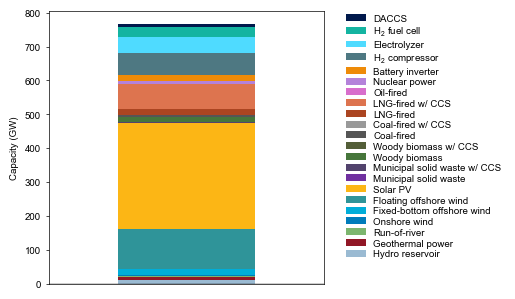

In [36]:
# Capacity

capacity_tech = optimal[optimal.id == 'cap'].groupby('general').sum()['value'] / 1000 # MW -> GW
df_capacity = pd.DataFrame(capacity_tech, columns=['value']).T
if int(YEAR) > 2020:
    df_capacity = df_capacity.loc[:,RESOURCE + BIOMASS + THERMAL + ['stpcs'] + ['h2cmp','el-h2','h2-el'] + ['daccs']]
else:
    df_capacity = df_capacity.loc[:,RESOURCE + BIOMASS + THERMAL + ['stpcs'] + ['h2cmp','el-h2','h2-el']]

technology_stack_plot(df_capacity, "Capacity (GW)", f'output/{model_name}/capacity_{model_name}.jpg', legend_col=1)


# Export
capacity_region = optimal[optimal.id == 'cap'].groupby(['region','general']).sum()['value'].reset_index()
capacity_region['year'] = YEAR
capacity_region.to_csv('output/%s/capacity_region_%s.csv' % (model_name,model_name), index=False)
capacity_total = capacity_region.groupby(['general'])['value'].sum()
capacity_total.to_csv('output/%s/capacity_%s.csv' % (model_name,model_name), header=['MW'])

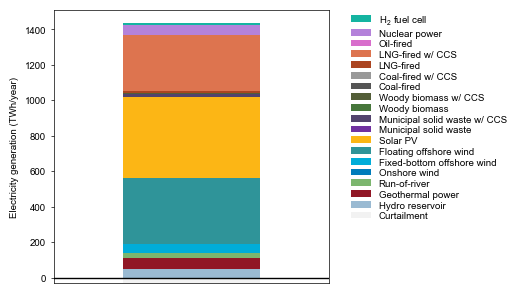

In [37]:
# Power mix
power_mix_dict = {}

cap_region = optimal[optimal.id == 'cap'].groupby(['region','general']).sum()
gen_region = optimal[optimal.id == 'gen'].groupby(['region','general']).sum()
crt_region = optimal[optimal.id == 'crt'].groupby('region').sum()['value']

for city in sorted(REGION):
    if city in SUBSTATION:
        local_power_mix = [max(round(cap_region.loc[(city,res)].value * profile[res][city].sum()), 0) for res in RESOURCE] + [(max(round(gen_region.loc[(city,f)].value), 0) if ((city,f) in gen_region.index) else 0) for f in BIOMASS+THERMAL] + [max(gen_region.loc[(city,'h2-el')].value, 0) if city in SPREGION['h2'] else 0]
    else:
        local_power_mix = [max(round(cap_region.loc[(city,res)].value * profile[res][city].sum()), 0) for res in RESOURCE] + [0 for n in BIOMASS + THERMAL + ['h2-el']]

    local_power_mix.insert(0,-crt_region[city])
    power_mix_dict[city] = local_power_mix

power_mix = pd.DataFrame(data=power_mix_dict, index=['crt']+RESOURCE+BIOMASS+THERMAL+['h2-el']).T.loc[REGION]
power_mix_total = power_mix.sum() / 1000000 # MWh -> TWh
df_power_mix = pd.DataFrame(power_mix_total, columns=['value']).T
technology_stack_plot(df_power_mix, "Electricity generation (TWh/year)", f'output/{model_name}/generation_{model_name}.jpg', legend_col=1)


# Export
power_mix.to_csv('output/%s/generation_region_%s.csv' % (model_name,model_name))
power_mix.sum().to_csv('output/%s/generation_%s.csv' % (model_name,model_name), header=['MWh'])

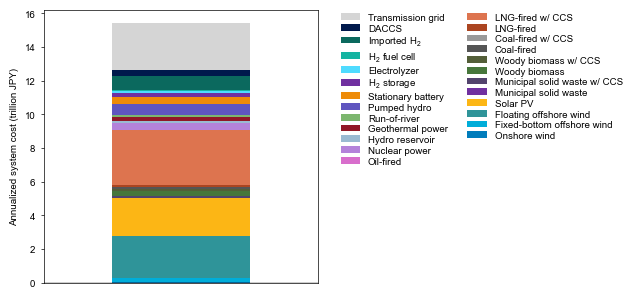

15.447256827452208 trillion JPY
11.397853846921642 JPY/kWh


In [38]:
# System costs
system_cost = pd.Series()

# Fixed cost
cap = optimal[optimal.id == 'cap'][['general','value']].groupby(['general'], as_index=['general']).sum()
system_cost = cap['value'] * P['fixed_cost']
system_cost['stbat'] += system_cost['stpcs']
system_cost['st-h2'] += system_cost['h2cmp']
system_cost = system_cost.loc[RESOURCE + BIOMASS + THERMAL + STORAGE + H2TECH + ['daccs']]

# Grid cost
cost_grid = optimal[(optimal.id == 'grd') & (optimal.value > 0)]
cost_grid.loc[:, 'region'] = cost_grid['region'].astype(str)
cost_grid = cost_grid.set_index(['region','general'])['value'] 
for pair in cost_grid.index:
    cost_grid[pair] = cost_grid[pair] * grid_cost[pair[0]][pair[1]]

# Variable cost
cost_fuel = optimal[optimal.id == 'gen'].groupby(['general'], as_index=['general'])['value'].sum()
for tech in BIOMASS + THERMAL:
    system_cost[tech] += cost_fuel[tech] * P['variable_cost'][tech] * T_EXPAND

# DACCS
cost_dac = optimal[optimal.id == 'dac']['value'].sum() * P['variable_cost']['daccs']
system_cost['daccs'] += cost_dac * T_EXPAND

# Fuel import cost
cost_ih2 = optimal[optimal.id == 'ih2']['value'].sum() * P['variable_cost']['ih2-f']
system_cost['ih2-f'] = cost_ih2 * T_EXPAND


# Small cost
small_cost = 0.00001 # 0.01 JPY/kWh

# charging
cost_chg = optimal[(optimal.id == 'chg') & (optimal.value > 0)].groupby('general').sum()['value']
cost_dcg = optimal[(optimal.id == 'dcg') & (optimal.value > 0)].groupby('general').sum()['value']
for st in STORAGE:
    try:
        system_cost[st] += (cost_chg[st] + cost_dcg[st]) * small_cost * T_EXPAND
    except:
        system_cost[st] = 0

# export
cost_exp = optimal[(optimal.id == 'exp') & (optimal.value > 0)].groupby(['region','general'], as_index=False)['value'].sum()
cost_exp['region'] = cost_exp['region'].astype(str)
cost_exp['general'] = cost_exp['general'].astype(str)
cost_exp = cost_exp.set_index(['region','general'])['value'] * small_cost * T_EXPAND

# import
cost_imp = optimal[(optimal.id == 'imp') & (optimal.value > 0)].groupby(['region','general'], as_index=False)['value'].sum()
cost_imp['region'] = cost_imp['region'].astype(str)
cost_imp['general'] = cost_imp['general'].astype(str)
cost_imp = cost_imp.set_index(['region','general'])['value'] * small_cost * T_EXPAND
system_cost['grid'] = cost_grid.sum() + cost_exp.sum() + cost_imp.sum()

# hydrogen
system_cost['st-h2'] += (optimal[optimal.id == 'hcg']['value'].sum() + optimal[optimal.id == 'hdg']['value'].sum()) * small_cost * T_EXPAND
system_cost['el-h2'] += optimal[optimal.id == 'prd']['value'].sum() * small_cost * T_EXPAND


# Sort index
system_cost = system_cost.reindex(['onwin','of-fx','of-fl','solar'] + BIOMASS + THERMAL + ['hydro','geoth','river'] + STORAGE + H2TECH + ['ih2-f','daccs'] + ['grid'])
tech_list = system_cost.index.to_list()

# Draw
system_cost = system_cost / 1000000 # million -> trillion
df_system_cost = system_cost.to_frame(model_name).T
technology_stack_plot(df_system_cost, "Annualized system cost (trillion JPY)", f'output/{model_name}/cost_{model_name}.jpg', legend_col=2)

# Export
total_cost = system_cost.sum().sum()
total_demand = regional_future_demand.sum().sum() + h2.sum().sum() #+ DC_demand_TWh[DC_SCENARIO][YEAR]*1000000
unit_cost = total_cost/total_demand*1000000000 # trillion JPY/MWh -> JPY/kWh
cost_summary = pd.Series(index=['system_cost','unit_cost'], data=[total_cost, unit_cost])
cost_summary.to_csv('output/%s/cost_total_%s.csv' % (model_name,model_name))
system_cost.to_csv('output/%s/cost_%s.csv' % (model_name,model_name), header=['trillion_JPY'])

print(total_cost, 'trillion JPY')
print(unit_cost, 'JPY/kWh')

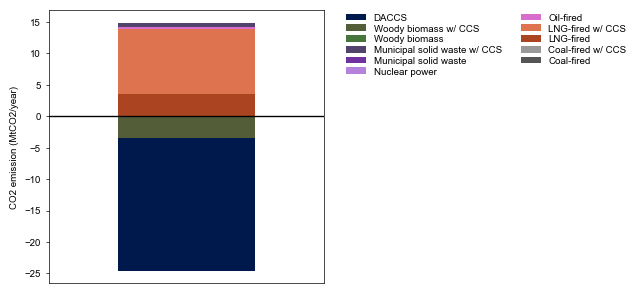

In [39]:
# CO2 emission

emission = df_power_mix.T['value'].loc[THERMAL+BIOMASS].copy()

for fuel in THERMAL+BIOMASS:
    if fuel == 'beccs':
        emission['beccs'] = -1*emission['beccs'] / P['ef']['beccs'] * P['cdr']['beccs']
    else:
        emission[fuel] = emission[fuel] / P['ef'][fuel] * P['cef'][fuel]

emission['daccs'] = -1*optimal[optimal.id == 'dac']['value'].sum() * P['cdr']['daccs']/1000000

df_emission = emission.to_frame(model_name).T
technology_stack_plot(df_emission, "CO2 emission (MtCO2/year)", f'output/{model_name}/emission_{model_name}.jpg', legend_col=2)

# Export
emission.to_csv('output/%s/emission_%s.csv' % (model_name,model_name), header=['MtCO2'])